# Proyecto Final — Sistemas Inteligentes II
## Aprendizaje por Transferencia en Visión por Computador

Asignatura: Sistemas Inteligentes II — Universidad de Caldas

Profesor: Jorge Alberto Jaramillo Garzón

Integrantes: Daniela Agudelo Martínez, Andersson Julián López Martínez

---

### Dominio 
Clasificación de enfermedades en hojas de tomate a partir de imágenes, usando un modelo
convolucional preentrenado en ImageNet (MobileNetV2) como base de transferencia.

### Pregunta experimental / Hipótesis
> ¿El descongelamiento parcial (fine-tuning) de las últimas capas de MobileNetV2 mejora el
> F1-score frente a usar el modelo únicamente como extractor de características (capas congeladas),
> y cuál es el costo computacional adicional de esa mejora?

Hipótesis (H1): El fine-tuning parcial obtendrá un F1-score macro superior al del extractor
de características congelado, a costa de un mayor tiempo de entrenamiento y mayor riesgo de
sobreajuste.

### Configuraciones comparadas
| | Config A — *Feature Extractor* | Config B — *Fine-Tuning parcial* |
|---|---|---|
| Backbone MobileNetV2 | Congelado (no entrenable) | Últimas capas descongeladas |
| Capas entrenadas | Solo el clasificador (head) | Head + bloque superior del backbone |
| Learning rate | 1e-3 | 1e-3 (head) → 1e-5 (fine-tuning) |

Ambas configuraciones comparten dataset, particiones, semilla, *data augmentation* y arquitectura
del clasificador; lo único que cambia es la estrategia de transferencia, lo que aísla la
variable bajo estudio.

## 1. Configuración del entorno e importación de librerías

Este notebook está pensado para ejecutarse en una GPU local estándar o en Google Colab.
El dataset PlantVillage se carga desde la carpeta local Plant_leaf_diseases_dataset_without_augmentation
(descargado manualmente)

In [ ]:
# Instalación de dependencias
# %pip install tensorflow scikit-learn matplotlib seaborn pandas

In [29]:
import os
import time
import random
import platform
import pathlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Reproducibilidad y registro de metadatos

Se pretende reportar modelo, dataset, particiones, tamaño de
entrada, épocas, optimizador y learning rate, batch size, técnica de transferencia, hardware,
tiempo de entrenamiento y semilla aleatoria. Aquí fijamos la semilla y detectamos el hardware;
el resto de metadatos se irá registrando en el diccionario META a lo largo del notebook.

In [30]:
# ----------------------------------------------------------------------------
# Hiperparámetros y configuración global del experimento
# ----------------------------------------------------------------------------
SEED          = 42            # Semilla aleatoria para reproducibilidad
IMG_SIZE      = (160, 160)    # Tamaño de entrada esperado por el backbone
BATCH_SIZE    = 32            # Tamaño de lote

# Excluimos Tomato mosaic virus (solo 373 img en PlantVillage): es la clase
# minoritaria y limitaba el submuestreo balanceado a 373/clase. Sin ella, el
# mínimo entre las 9 clases restantes es Leaf Mold (952) → más muestras/clase.
EXCLUDED_CLASSES = ["Tomato mosaic virus"]
MAX_PER_CLASS    = 952        # Imágenes por clase 
VAL_SPLIT     = 0.15          # Proporción de validación interna (EarlyStopping)
EPOCHS_HEAD   = 12            # Épocas para entrenar el clasificador (head)
EPOCHS_FT     = 8             # Épocas adicionales de fine-tuning (solo Config B)
LR_HEAD       = 1e-3          # Learning rate del clasificador
LR_FINETUNE   = 1e-5          # Learning rate (bajo) para el descongelamiento
FINE_TUNE_AT  = 120           # A partir de qué capa de MobileNetV2 se descongela (Config B)


def set_seeds(seed: int = SEED):
    """Fija todas las fuentes de aleatoriedad para que el experimento sea reproducible."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seeds(SEED)
print(f"Semilla aleatoria fijada en: {SEED}")

Semilla aleatoria fijada en: 42


In [31]:
# ----------------------------------------------------------------------------
# Detección de hardware (CPU / GPU) y registro de metadatos del entorno
# ----------------------------------------------------------------------------
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    try:
        gpu_name = tf.config.experimental.get_device_details(gpus[0]).get("device_name", "GPU")
    except Exception:
        gpu_name = "GPU"
    device_str = f"CUDA / GPU ({gpu_name})"
else:
    device_str = "CPU"

META = {
    "modelo_base": "MobileNetV2 (ImageNet)",
    "dataset": "PlantVillage - subconjunto Tomate",
    "tamano_entrada": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "semilla": SEED,
    "hardware": device_str,
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
}

print("Hardware detectado:", device_str)
print("Núm. de GPUs disponibles:", len(gpus))
for k, v in META.items():
    print(f"  - {k}: {v}")

Hardware detectado: CPU
Núm. de GPUs disponibles: 0
  - modelo_base: MobileNetV2 (ImageNet)
  - dataset: PlantVillage - subconjunto Tomate
  - tamano_entrada: (160, 160)
  - batch_size: 32
  - semilla: 42
  - hardware: CPU
  - python: 3.11.9
  - tensorflow: 2.21.0


## 3. Carga y preprocesamiento del dataset

Usamos PlantVillage desde la carpeta local Plant_leaf_diseases_dataset_without_augmentation.
El dataset completo tiene ~54.000 imágenes en 38 clases; nos centramos en el subconjunto de
hojas de tomate.

PlantVillage incluye 10 carpetas Tomato___*.
Excluimos Tomato mosaic virus (373 imágenes, la clase más pequeña) para poder submuestrear
las 9 clases restantes de forma balanceada a 952 imágenes por clase (mínimo de Leaf Mold).

En lugar de un único reparto fijo, usamos validación
cruzada estratificada de N_SPLITS folds. En cada fold, el resto de los datos se usa para
entrenar (con una pequeña partición interna de validación para EarlyStopping) y el fold reservado
se usa como prueba. Esto reduce el sesgo de un único split y permite reportar las
métricas como media ± desviación estándar entre folds.

In [ ]:
DATA_ROOT = pathlib.Path("Plant_leaf_diseases_dataset_without_augmentation")

if (DATA_ROOT / "Plant_leave_diseases_dataset_without_augmentation").is_dir():
    DATA_DIR = DATA_ROOT / "Plant_leave_diseases_dataset_without_augmentation"
elif any(DATA_ROOT.iterdir()):
    DATA_DIR = next(p for p in DATA_ROOT.iterdir() if p.is_dir())
else:
    DATA_DIR = DATA_ROOT

print("Carpeta de datos:", DATA_DIR.resolve())

tomato_dirs_all = sorted(
    d for d in DATA_DIR.iterdir()
    if d.is_dir() and d.name.lower().startswith("tomato")
)
tomato_dirs = [
    d for d in tomato_dirs_all
    if d.name.replace("Tomato___", "").replace("_", " ") not in EXCLUDED_CLASSES
]
CLASS_NAMES = [
    d.name.replace("Tomato___", "").replace("_", " ")
    for d in tomato_dirs
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nClases excluidas: {EXCLUDED_CLASSES}")
print(f"MAX_PER_CLASS (balanceado): {MAX_PER_CLASS}")
print(f"\nClases de tomate seleccionadas ({NUM_CLASSES}):")
for new_lbl, name in enumerate(CLASS_NAMES):
    print(f"  {new_lbl}: {name}")

META["num_clases"] = NUM_CLASSES
META["clases"] = CLASS_NAMES
META["clases_excluidas"] = EXCLUDED_CLASSES
META["max_per_class"] = MAX_PER_CLASS
META["motivo_exclusion"] = (
    "Tomato mosaic virus excluida (373 img) para submuestrear 9 clases a 952/clase "
    "(mínimo de Leaf Mold) en lugar de 373/clase con las 10 clases."
)
META["ruta_dataset"] = str(DATA_DIR.resolve())

Carpeta de datos: C:\Users\USUARIO\Documents\Inteligentes\Proyecto\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation

Clases excluidas: ['Tomato mosaic virus']
MAX_PER_CLASS (balanceado): 952

Clases de tomate seleccionadas (9):
  0: Bacterial spot
  1: Early blight
  2: healthy
  3: Late blight
  4: Leaf Mold
  5: Septoria leaf spot
  6: Spider mites Two-spotted spider mite
  7: Target Spot
  8: Tomato Yellow Leaf Curl Virus


In [33]:
# Recorremos las carpetas de tomate, redimensionamos a IMG_SIZE y llenamos
# por clase hasta MAX_PER_CLASS (subconjunto balanceado en memoria).
IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

set_seeds(SEED)
buckets = defaultdict(list)
rng = np.random.default_rng(SEED)

for local, class_dir in enumerate(tomato_dirs):
    paths = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXT
    ]
    rng.shuffle(paths)
    for img_path in paths[:MAX_PER_CLASS]:
        img_bytes = tf.io.read_file(str(img_path))
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img_resized = tf.image.resize(img, IMG_SIZE).numpy().astype("uint8")
        buckets[local].append(img_resized)

# Construimos los arreglos X (imágenes) e y (etiquetas)
X = np.concatenate([np.stack(buckets[c]) for c in range(NUM_CLASSES)], axis=0)
y = np.concatenate([np.full(len(buckets[c]), c, dtype=np.int64) for c in range(NUM_CLASSES)])

print("Forma de X:", X.shape, "| Forma de y:", y.shape)
print("Imágenes por clase:")
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<28} -> {len(buckets[c])}")

Forma de X: (8568, 160, 160, 3) | Forma de y: (8568,)
Imágenes por clase:
  Bacterial spot               -> 952
  Early blight                 -> 952
  healthy                      -> 952
  Late blight                  -> 952
  Leaf Mold                    -> 952
  Septoria leaf spot           -> 952
  Spider mites Two-spotted spider mite -> 952
  Target Spot                  -> 952
  Tomato Yellow Leaf Curl Virus -> 952


In [34]:
# ----------------------------------------------------------------------------
# Validación cruzada estratificada 
# ----------------------------------------------------------------------------
# Repetimos el experimento en N_SPLITS particiones distintas y reportamos
# media ± desviación estándar. Así las diferencias entre Config A y B no dependen
# de un único reparto afortunado de los datos.

N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Validación cruzada estratificada con {N_SPLITS} folds.")
print(f"Cada fold entrena con ~{(N_SPLITS - 1) / N_SPLITS * 100:.0f}% de los datos "
      f"y prueba con ~{100 / N_SPLITS:.0f}%.")
print(f"Validación interna (EarlyStopping): {VAL_SPLIT:.0%} del subconjunto de entrenamiento.")

META["validacion"] = f"StratifiedKFold ({N_SPLITS} folds)"
META["particiones"] = {
    "esquema": f"{N_SPLITS}-fold CV estratificada",
    "val_interna": VAL_SPLIT,
}

Validación cruzada estratificada con 5 folds.
Cada fold entrena con ~80% de los datos y prueba con ~20%.
Validación interna (EarlyStopping): 15% del subconjunto de entrenamiento.


In [35]:
# Construcción de los DataLoaders con tf.data.
# Aplicamos preprocess_input de MobileNetV2.
AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(X_arr, y_arr, training=False):
    """Crea un tf.data.Dataset con preprocesamiento, barajado (solo train), lotes y prefetch."""
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    if training:
        ds = ds.shuffle(buffer_size=len(X_arr), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda img, lbl: (preprocess_input(tf.cast(img, tf.float32)), lbl),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("Función make_dataset y data augmentation listas.")

Función make_dataset y data augmentation listas.


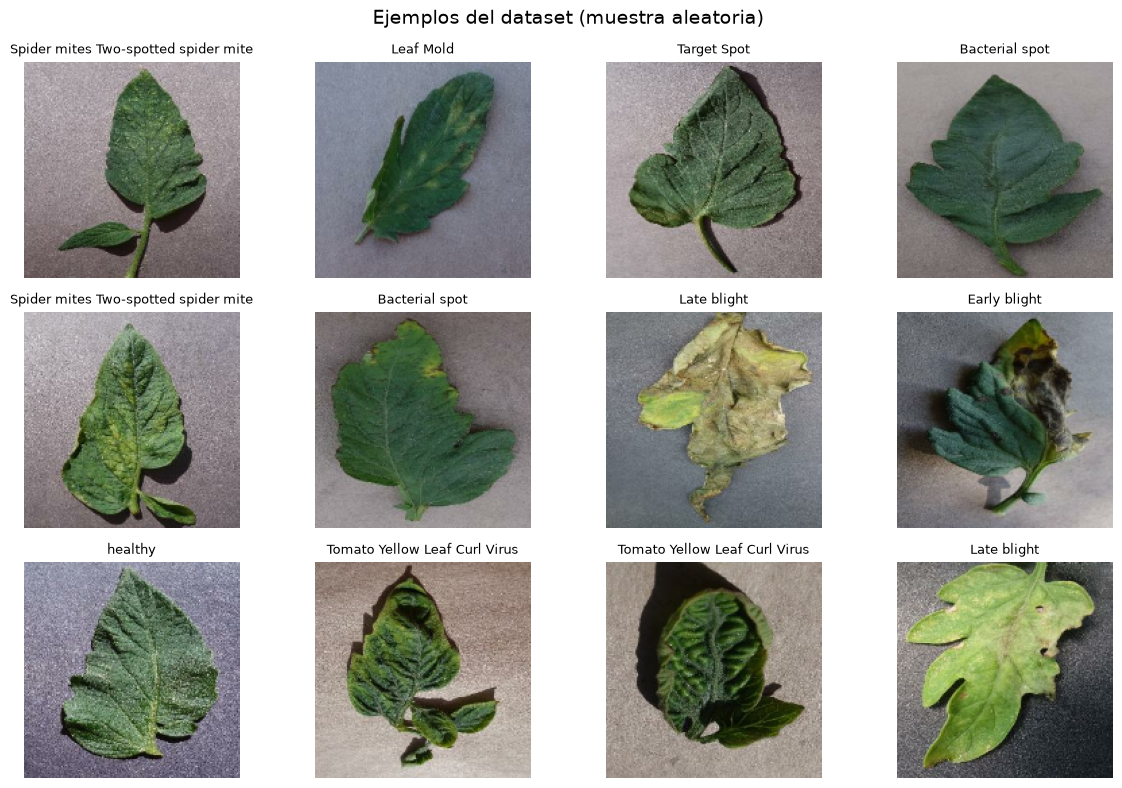

In [36]:
# Visualización de ejemplos del dataset (antes de normalizar)
set_seeds(SEED)
sample_idx = np.random.choice(len(X), size=12, replace=False)
plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_idx):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[idx])
    plt.title(CLASS_NAMES[y[idx]], fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset (muestra aleatoria)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Arquitectura del modelo (MobileNetV2)

Definimos una función modular build_model que construye el mismo clasificador para ambas
configuraciones. El parámetro fine_tune_at controla la estrategia de transferencia:

- fine_tune_at = None → backbone totalmente congelado (Config A, extractor de características).
- fine_tune_at = k → se descongelan las capas del backbone a partir del índice k (Config B).

Nota: invocamos el backbone con training=False para mantener las capas de
*BatchNormalization* en modo inferencia, la cual es una práctica recomendada al hacer fine-tuning para no
desestabilizar las estadísticas preentrenadas.

In [37]:
def build_model(num_classes: int, fine_tune_at=None):
    """Construye el modelo de transferencia sobre MobileNetV2.

    Parámetros
    ----------
    num_classes : int
        Número de clases de salida.
    fine_tune_at : int | None
        - None  -> backbone congelado (Config A: extractor de características).
        - int k -> se descongelan las capas del backbone desde el índice k (Config B).
    """
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,          # quitamos el clasificador original de ImageNet
        weights="imagenet",
    )

    if fine_tune_at is None:
        base_model.trainable = False                # Config A: todo congelado
    else:
        base_model.trainable = True                 # Config B: descongelamiento parcial
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False                 # capas inferiores quedan congeladas

    inputs = Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)                   # aumento de datos (solo en training)
    x = base_model(x, training=False)               # BatchNorm en modo inferencia
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)                      # regularización para mitigar sobreajuste
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model, base_model


# Prueba rápida de construcción (Config A) y resumen de la arquitectura
_demo_model, _demo_base = build_model(NUM_CLASSES, fine_tune_at=None)
_demo_model.summary()
del _demo_model, _demo_base

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Estrategia de entrenamiento y funciones de evaluación

- Función de pérdida: sparse_categorical_crossentropy (etiquetas enteras, salida softmax).
- Optimizador: Adam.
- Métrica de monitoreo: accuracy (validación), con EarlyStopping para evitar sobreajuste.
- Registro de metadatos: medimos el tiempo de entrenamiento y el número de épocas reales.

Las funciones train_model, plot_history, evaluate_model y show_examples son reutilizadas
por ambas configuraciones para garantizar una comparación justa.

In [38]:
def compile_model(model, learning_rate):
    """Compila el modelo con Adam y entropía cruzada categórica dispersa."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def train_model(model, train_ds, val_ds, epochs, initial_epoch=0, history_prev=None, verbose=1):
    """Entrena el modelo midiendo el tiempo y devuelve (history_dict, tiempo_segundos)."""
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True)

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=[early_stop],
        verbose=verbose,
    )
    elapsed = time.time() - start

    # Permite concatenar el historial de fases (head + fine-tuning) en Config B
    hist = history.history
    if history_prev is not None:
        hist = {k: history_prev.get(k, []) + v for k, v in hist.items()}
    return hist, elapsed


def count_trainable_params(model):
    """Devuelve (entrenables, totales) en número de parámetros."""
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_variables]))
    total = int(np.sum([np.prod(v.shape) for v in model.variables]))
    return trainable, total

In [39]:
def plot_history(hist, title=""):
    """Grafica las curvas de aprendizaje (pérdida y accuracy) por época."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(hist["loss"], label="Entrenamiento")
    axes[0].plot(hist["val_loss"], label="Validación")
    axes[0].set_title(f"Pérdida (Loss) — {title}")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist["accuracy"], label="Entrenamiento")
    axes[1].plot(hist["val_accuracy"], label="Validación")
    axes[1].set_title(f"Exactitud (Accuracy) — {title}")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_predictions(model, ds):
    """Devuelve (y_true, y_pred) para un dataset dado."""
    y_true, y_pred = [], []
    for batch_x, batch_y in ds:
        probs = model.predict(batch_x, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(batch_y.numpy())
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, ds, config_name="", verbose=True):
    """Calcula accuracy, precision, recall y F1 (macro). Imprime el detalle si verbose=True."""
    y_true, y_pred = get_predictions(model, ds)

    metrics = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1":        f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

    if verbose:
        print(f"\n===== Métricas — {config_name} =====")
        for k, v in metrics.items():
            print(f"  {k:<10}: {v:.4f}")
        print("\nReporte de clasificación por clase:")
        print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    else:
        print(f"  [{config_name}] acc={metrics['accuracy']:.3f}  f1={metrics['f1']:.3f}")

    return metrics, y_true, y_pred


def plot_confusion(y_true, y_pred, title=""):
    """Grafica la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Matriz de confusión — {title}")
    plt.xlabel("Predicción"); plt.ylabel("Real")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [40]:
def show_examples(model, X_eval, y_eval, eval_ds, correct=True, n=8, title=""):
    """Muestra ejemplos bien clasificados (correct=True) o mal clasificados (correct=False).

    Las imágenes se toman del conjunto de evaluación (X_eval) en su forma original (uint8).
    """
    probs = model.predict(eval_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)

    if correct:
        idxs = np.where(preds == y_eval)[0]
    else:
        idxs = np.where(preds != y_eval)[0]

    if len(idxs) == 0:
        print(f"No hay ejemplos {'correctos' if correct else 'incorrectos'} para mostrar.")
        return

    idxs = idxs[:n]
    plt.figure(figsize=(14, 7))
    for i, idx in enumerate(idxs):
        plt.subplot(2, 4, i + 1)
        plt.imshow(X_eval[idx])
        color = "green" if correct else "red"
        plt.title(f"Real: {CLASS_NAMES[y_eval[idx]]}\n"
                  f"Pred: {CLASS_NAMES[preds[idx]]} ({confidences[idx]:.2f})",
                  fontsize=9, color=color)
        plt.axis("off")
    estado = "BIEN clasificados" if correct else "MAL clasificados"
    plt.suptitle(f"Ejemplos {estado} — {title}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Entrenamiento con validación cruzada

En lugar de un único split fijo, usamos validación cruzada estratificada de N_SPLITS folds.
En cada fold entrenamos ambas configuraciones sobre las mismas particiones y evaluamos en el fold
de prueba correspondiente:

- Config A — Extractor de características: backbone MobileNetV2 congelado, solo se entrena el
  clasificador (head). Línea base de menor costo.
- Config B — Fine-tuning parcial: dos fases (calentamiento del head + descongelamiento de las
  capas superiores con learning rate bajo).

Las métricas finales se reportan como media ± desviación estándar entre folds, de modo que la
comparación A vs. B no dependa de un único reparto afortunado de los datos.

In [41]:
# Funciones que entrenan cada configuración dado un par (train_ds, val_ds).
# Se reutilizan en cada fold de la validación cruzada para una comparación justa.

def run_config_A(train_ds, val_ds):
    """Config A — extractor de características (backbone congelado)."""
    set_seeds(SEED)                       # mismo punto de partida en cada fold/config
    model, _ = build_model(NUM_CLASSES, fine_tune_at=None)
    compile_model(model, learning_rate=LR_HEAD)
    history, elapsed = train_model(model, train_ds, val_ds,
                                   epochs=EPOCHS_HEAD, verbose=0)
    return model, history, elapsed


def run_config_B(train_ds, val_ds):
    """Config B — fine-tuning parcial en dos fases (calentamiento + descongelamiento)."""
    set_seeds(SEED)
    # Fase 1: calentamiento del head con el backbone congelado
    model, base = build_model(NUM_CLASSES, fine_tune_at=None)
    compile_model(model, learning_rate=LR_HEAD)
    history, t1 = train_model(model, train_ds, val_ds,
                              epochs=EPOCHS_HEAD, verbose=0)
    # Fase 2: descongelar capas superiores y reentrenar con learning rate bajo
    base.trainable = True
    for layer in base.layers[:FINE_TUNE_AT]:
        layer.trainable = False           # capas inferiores siguen congeladas
    compile_model(model, learning_rate=LR_FINETUNE)
    history, t2 = train_model(model, train_ds, val_ds,
                              epochs=len(history["loss"]) + EPOCHS_FT,
                              initial_epoch=len(history["loss"]),
                              history_prev=history, verbose=0)
    return model, history, t1 + t2

print("Funciones run_config_A y run_config_B listas.")

Funciones run_config_A y run_config_B listas.


In [42]:
# ----------------------------------------------------------------------------
# Bucle de validación cruzada: en cada fold entrenamos A y B y recogemos métricas.
# (Aviso: entrena 2 modelos por fold; con N_SPLITS=5 son 10 entrenamientos.
#  En CPU puede tardar bastante; reduce EPOCHS, MAX_PER_CLASS o N_SPLITS si lo necesitas.)
# ----------------------------------------------------------------------------
cv_metrics = {"A": [], "B": []}
cv_times   = {"A": [], "B": []}
oof_true   = {"A": [], "B": []}   # etiquetas reales out-of-fold (matriz de confusión global)
oof_pred   = {"A": [], "B": []}   # predicciones out-of-fold
last_hist = {}; last_models = {}; trainable_counts = {}; last_test = None

for fold, (trainval_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== FOLD {fold}/{N_SPLITS} ==========")
    X_tv, y_tv = X[trainval_idx], y[trainval_idx]
    X_te, y_te = X[test_idx],     y[test_idx]

    # Validación interna (estratificada) para EarlyStopping
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tv, y_tv, test_size=VAL_SPLIT, stratify=y_tv, random_state=SEED)

    train_ds = make_dataset(X_tr, y_tr, training=True)
    val_ds   = make_dataset(X_va, y_va, training=False)
    test_ds  = make_dataset(X_te, y_te, training=False)

    # ---- Config A: backbone congelado ----
    model_A, hist_A, time_A = run_config_A(train_ds, val_ds)
    m_A, yt_A, yp_A = evaluate_model(model_A, test_ds, f"A fold {fold}", verbose=False)
    cv_metrics["A"].append(m_A); cv_times["A"].append(time_A)
    oof_true["A"].extend(yt_A);  oof_pred["A"].extend(yp_A)

    # ---- Config B: fine-tuning parcial (2 fases) ----
    model_B, hist_B, time_B = run_config_B(train_ds, val_ds)
    m_B, yt_B, yp_B = evaluate_model(model_B, test_ds, f"B fold {fold}", verbose=False)
    cv_metrics["B"].append(m_B); cv_times["B"].append(time_B)
    oof_true["B"].extend(yt_B);  oof_pred["B"].extend(yp_B)

    # Guardamos el último fold para curvas, matrices y ejemplos cualitativos
    last_hist = {"A": hist_A, "B": hist_B}
    last_models = {"A": model_A, "B": model_B}
    trainable_counts = {"A": count_trainable_params(model_A)[0],
                        "B": count_trainable_params(model_B)[0]}
    last_test = (X_te, y_te, test_ds)

print("\nValidación cruzada completada.")


========== FOLD 1/5 ==========
  [A fold 1] acc=0.835  f1=0.835
  [B fold 1] acc=0.871  f1=0.871

========== FOLD 2/5 ==========
  [A fold 2] acc=0.831  f1=0.829
  [B fold 2] acc=0.872  f1=0.871

========== FOLD 3/5 ==========
  [A fold 3] acc=0.826  f1=0.826
  [B fold 3] acc=0.860  f1=0.859

========== FOLD 4/5 ==========
  [A fold 4] acc=0.845  f1=0.844
  [B fold 4] acc=0.875  f1=0.873

========== FOLD 5/5 ==========
  [A fold 5] acc=0.852  f1=0.853
  [B fold 5] acc=0.859  f1=0.856

Validación cruzada completada.


## 7. Resultados agregados (media ± desviación estándar)

Promediamos las métricas de los N_SPLITS folds. La desviación estándar indica qué tan estable
es cada configuración frente al azar del reparto de datos y de la inicialización: si los intervalos
(media ± std) de A y B se solapan, la diferencia de F1 no es concluyente.

In [43]:
# ----------------------------------------------------------------------------
# Resultados agregados: media ± desviación estándar a través de los folds
# ----------------------------------------------------------------------------
def _stats(metric_list, key):
    vals = np.array([m[key] for m in metric_list])
    return vals.mean(), vals.std()

plot_stats = {}   # valores numéricos para los gráficos posteriores
filas = []
for cfg, nombre in [("A", "A — Congelado"), ("B", "B — Fine-tuning")]:
    acc_m, acc_s = _stats(cv_metrics[cfg], "accuracy")
    pre_m, pre_s = _stats(cv_metrics[cfg], "precision")
    rec_m, rec_s = _stats(cv_metrics[cfg], "recall")
    f1_m,  f1_s  = _stats(cv_metrics[cfg], "f1")
    t = np.array(cv_times[cfg])
    plot_stats[cfg] = {"f1_m": f1_m, "f1_s": f1_s, "t_m": t.mean(), "t_s": t.std()}
    filas.append({
        "Configuración": nombre,
        "Accuracy":   f"{acc_m:.3f} ± {acc_s:.3f}",
        "Precision":  f"{pre_m:.3f} ± {pre_s:.3f}",
        "Recall":     f"{rec_m:.3f} ± {rec_s:.3f}",
        "F1 (macro)": f"{f1_m:.3f} ± {f1_s:.3f}",
        "Tiempo (s)": f"{t.mean():.1f} ± {t.std():.1f}",
        "Params entren.": trainable_counts[cfg],
    })

resumen = pd.DataFrame(filas)

META.update({
    "epocas_head": EPOCHS_HEAD,
    "epocas_finetune": EPOCHS_FT,
    "optimizador": "Adam",
    "lr_head": LR_HEAD,
    "lr_finetune": LR_FINETUNE,
    "tecnica_transferencia": "A: feature extraction | B: fine-tuning parcial",
    "f1_A_mean": round(plot_stats["A"]["f1_m"], 4),
    "f1_A_std":  round(plot_stats["A"]["f1_s"], 4),
    "f1_B_mean": round(plot_stats["B"]["f1_m"], 4),
    "f1_B_std":  round(plot_stats["B"]["f1_s"], 4),
    "tiempo_A_s_mean": round(plot_stats["A"]["t_m"], 1),
    "tiempo_B_s_mean": round(plot_stats["B"]["t_m"], 1),
})

print("===== RESUMEN COMPARATIVO (validación cruzada) =====")
display(resumen)
print("\n===== METADATOS DEL EXPERIMENTO =====")
for k, v in META.items():
    print(f"  {k}: {v}")

===== RESUMEN COMPARATIVO (validación cruzada) =====


,Configuración,Accuracy,Precision,Recall,F1 (macro),Tiempo (s),Params entren.
0,A — Congelado,0.838 ± 0.010,0.848 ± 0.008,0.838 ± 0.010,0.837 ± 0.010,1808.3 ± 325.1,11529
1,B — Fine-tuning,0.867 ± 0.007,0.874 ± 0.007,0.867 ± 0.007,0.866 ± 0.007,3569.8 ± 765.3,1636425



===== METADATOS DEL EXPERIMENTO =====
  modelo_base: MobileNetV2 (ImageNet)
  dataset: PlantVillage - subconjunto Tomate
  tamano_entrada: (160, 160)
  batch_size: 32
  semilla: 42
  hardware: CPU
  python: 3.11.9
  tensorflow: 2.21.0
  num_clases: 9
  clases: ['Bacterial spot', 'Early blight', 'healthy', 'Late blight', 'Leaf Mold', 'Septoria leaf spot', 'Spider mites Two-spotted spider mite', 'Target Spot', 'Tomato Yellow Leaf Curl Virus']
  clases_excluidas: ['Tomato mosaic virus']
  max_per_class: 952
  motivo_exclusion: Tomato mosaic virus excluida (373 img) para submuestrear 9 clases a 952/clase (mínimo de Leaf Mold) en lugar de 373/clase con las 10 clases.
  ruta_dataset: C:\Users\USUARIO\Documents\Inteligentes\Proyecto\Plant_leaf_diseases_dataset_without_augmentation\Plant_leave_diseases_dataset_without_augmentation
  validacion: StratifiedKFold (5 folds)
  particiones: {'esquema': '5-fold CV estratificada', 'val_interna': 0.15}
  epocas_head: 12
  epocas_finetune: 8
  optimiza

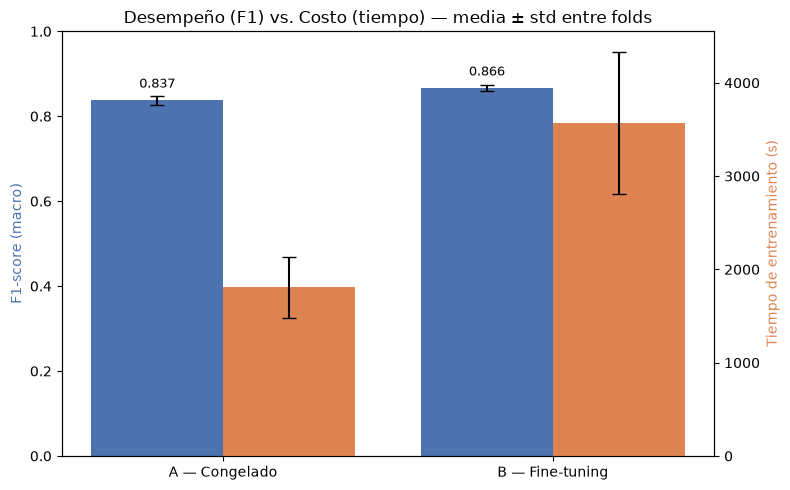

In [44]:
# Gráfico de barras con barras de error: F1 (macro) y tiempo, media ± std entre folds
configs  = ["A — Congelado", "B — Fine-tuning"]
f1_means = [plot_stats["A"]["f1_m"], plot_stats["B"]["f1_m"]]
f1_stds  = [plot_stats["A"]["f1_s"], plot_stats["B"]["f1_s"]]
t_means  = [plot_stats["A"]["t_m"],  plot_stats["B"]["t_m"]]
t_stds   = [plot_stats["A"]["t_s"],  plot_stats["B"]["t_s"]]
x = np.arange(len(configs))

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(x - 0.2, f1_means, yerr=f1_stds, width=0.4, capsize=5,
               label="F1 (macro)", color="#4C72B0")
ax1.set_ylabel("F1-score (macro)", color="#4C72B0")
ax1.set_ylim(0, 1)
for b, v in zip(bars, f1_means):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.3f}", ha="center", fontsize=9)

ax2 = ax1.twinx()
ax2.bar(x + 0.2, t_means, yerr=t_stds, width=0.4, capsize=5,
        label="Tiempo (s)", color="#DD8452")
ax2.set_ylabel("Tiempo de entrenamiento (s)", color="#DD8452")

ax1.set_xticks(x); ax1.set_xticklabels(configs)
plt.title("Desempeño (F1) vs. Costo (tiempo) — media ± std entre folds")
fig.tight_layout()
plt.show()

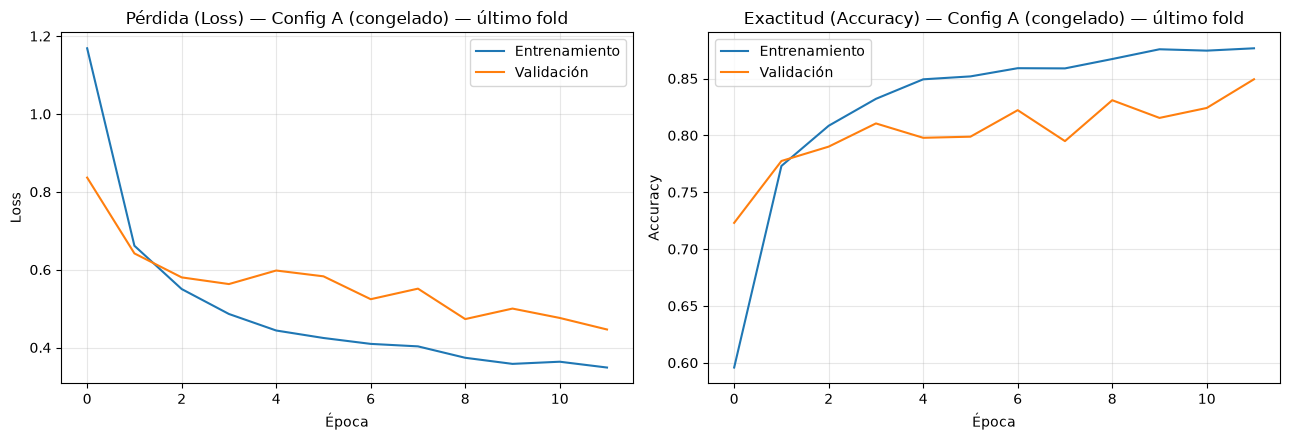

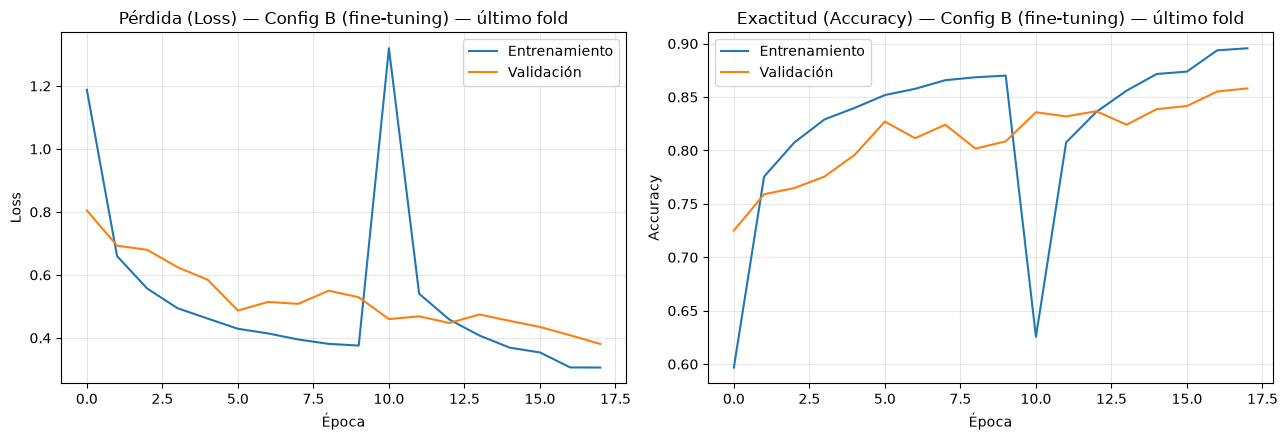

(En Config B, el fine-tuning comenzó en la época 12)


In [45]:
# Curvas de aprendizaje del ÚLTIMO fold (ejemplo representativo de cada configuración)
plot_history(last_hist["A"], title="Config A (congelado) — último fold")
plot_history(last_hist["B"], title="Config B (fine-tuning) — último fold")
print(f"(En Config B, el fine-tuning comenzó en la época {EPOCHS_HEAD})")

## 8. Matrices de confusión y análisis cualitativo

Construimos las matrices de confusión agregando las predicciones out-of-fold: cada muestra se
predice cuando cae en el fold de prueba, de modo que la matriz cubre todo el dataset una sola vez.
Para los ejemplos bien y mal clasificados usamos el modelo del último fold (Config B) como
ilustración.

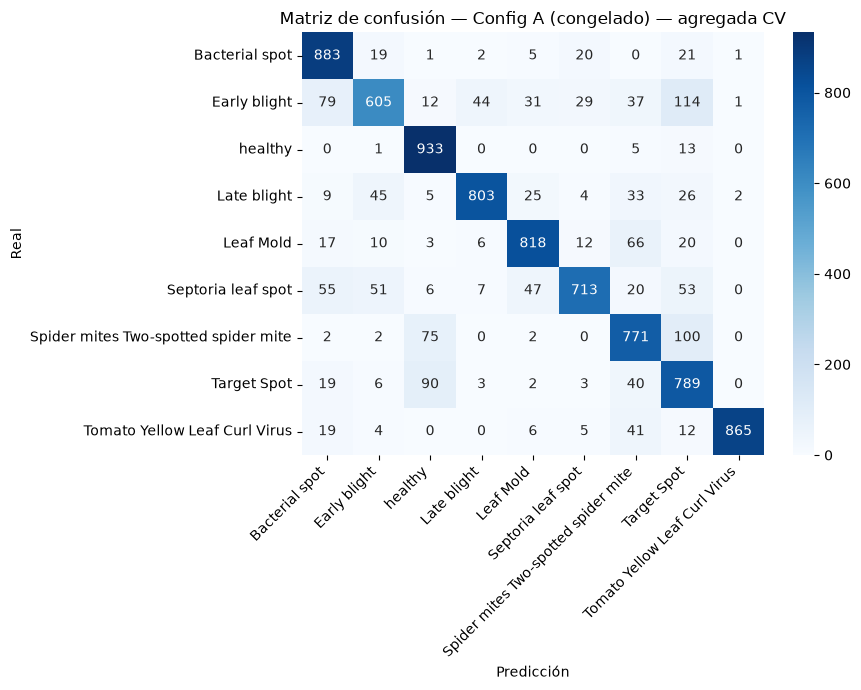

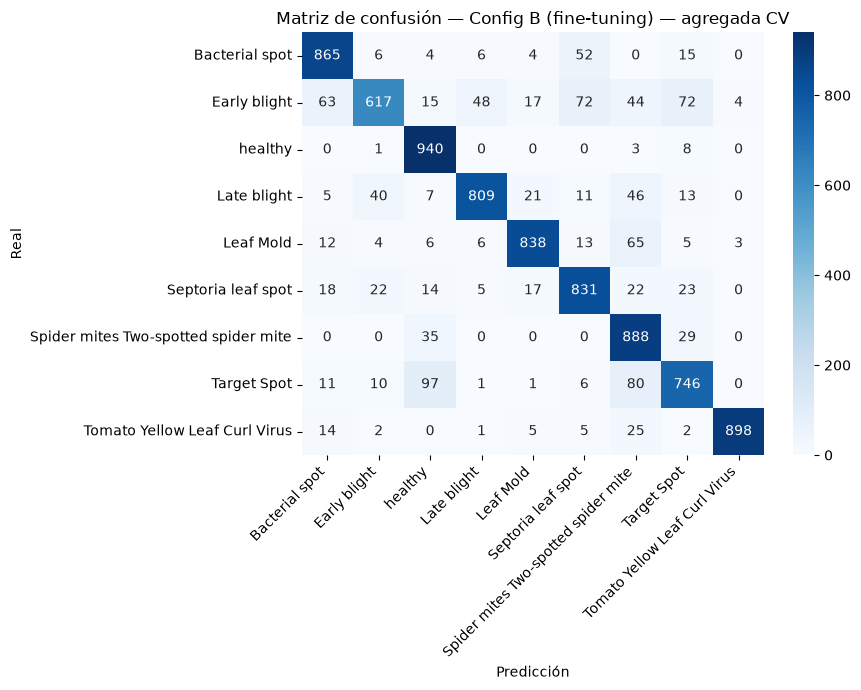

In [46]:
# Matrices de confusión agregadas (predicciones out-of-fold de TODOS los folds)
plot_confusion(np.array(oof_true["A"]), np.array(oof_pred["A"]),
               "Config A (congelado) — agregada CV")
plot_confusion(np.array(oof_true["B"]), np.array(oof_pred["B"]),
               "Config B (fine-tuning) — agregada CV")

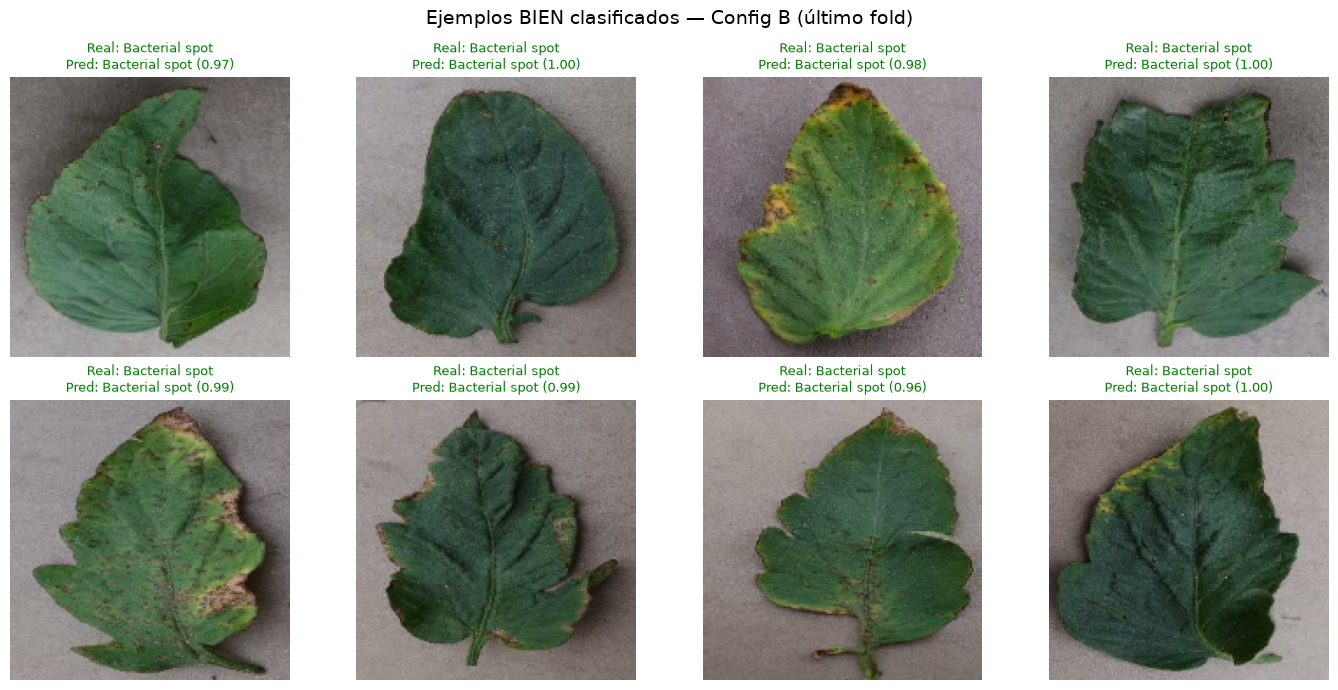

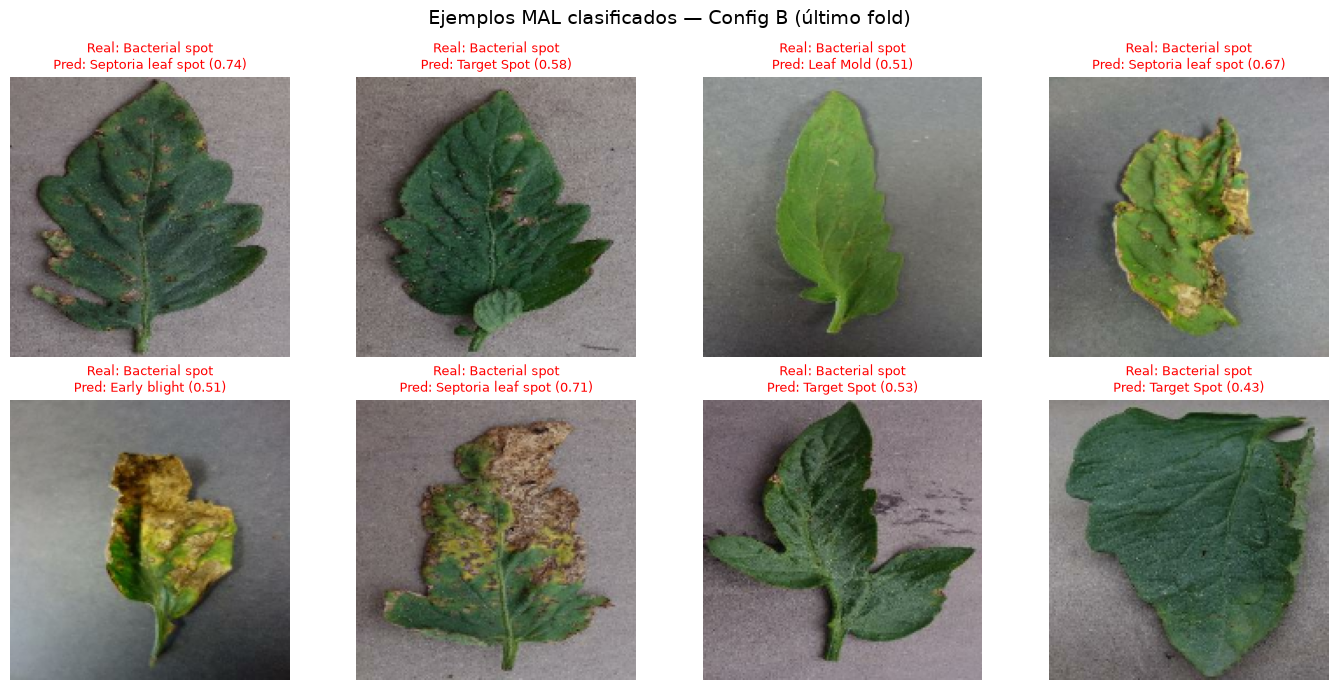

In [47]:
# Ejemplos bien y mal clasificados del último fold (mejor modelo: Config B)
X_te_last, y_te_last, test_ds_last = last_test
show_examples(last_models["B"], X_te_last, y_te_last, test_ds_last,
              correct=True,  n=8, title="Config B (último fold)")
show_examples(last_models["B"], X_te_last, y_te_last, test_ds_last,
              correct=False, n=8, title="Config B (último fold)")

In [48]:
# Detalle por fold (transparencia de la validación cruzada)
detalle = pd.DataFrame({
    "Fold": list(range(1, N_SPLITS + 1)),
    "F1 A": [round(m["f1"], 4) for m in cv_metrics["A"]],
    "F1 B": [round(m["f1"], 4) for m in cv_metrics["B"]],
    "Tiempo A (s)": [round(t, 1) for t in cv_times["A"]],
    "Tiempo B (s)": [round(t, 1) for t in cv_times["B"]],
})
print("===== F1 (macro) y tiempo por fold =====")
display(detalle)

===== F1 (macro) y tiempo por fold =====


,Fold,F1 A,F1 B,Tiempo A (s),Tiempo B (s)
0,1,0.8351,0.8707,2129.6,4755.1
1,2,0.8288,0.8713,2188.1,4148.0
2,3,0.8265,0.8593,1304.0,2664.5
3,4,0.8435,0.8727,1770.7,3116.2
4,5,0.8531,0.8560,1649.0,3165.3


## 9. Análisis e interpretación de resultados

### 9.1 Respuesta a la pregunta experimental y a la hipótesis H1

**Pregunta:** ¿El descongelamiento parcial (fine-tuning) de las últimas capas de MobileNetV2 mejora el F1-score frente a usar el modelo únicamente como extractor de características (capas congeladas), y cuál es el costo computacional adicional?

**Contexto del experimento final:** validación cruzada estratificada de **5 folds** sobre **8.568 imágenes** (9 clases de tomate, **952 img/clase balanceadas**). Se excluyó *Tomato mosaic virus* para elevar el submuestreo balanceado (mínimo de *Leaf Mold*). Entrenamiento en **CPU** (TensorFlow 2.21.0, Python 3.11.9).

**Resultado agregado (media ± desviación estándar entre folds):**

| Métrica | Config A (congelado) | Config B (fine-tuning) |
|---------|----------------------|-------------------------|
| F1 macro | 0.837 ± 0.010 | **0.866 ± 0.007** |
| Accuracy | 0.838 ± 0.010 | **0.867 ± 0.007** |
| Precision | 0.848 ± 0.008 | **0.874 ± 0.007** |
| Recall | 0.838 ± 0.010 | **0.867 ± 0.007** |

La **Config B supera a la A en las cuatro métricas** con una diferencia media de **ΔF1 = +0.029** (0.866 − 0.837). Los intervalos aproximados (media ± std) son **A: [0.827, 0.847]** y **B: [0.859, 0.873]**, con **poca superposición**, lo que refuerza que la mejora no es un artefacto de un único reparto afortunado.

**Costo computacional:** Config B tardó de media **3.569,8 ± 765,3 s por fold** frente a **1.808,3 ± 325,1 s** de A, es decir **~1,97× más tiempo** (casi el doble). En total, el experimento completo (5 folds × 2 configs) consumió del orden de **~2,5 h (A)** y **~5,0 h (B)** en CPU.

**Conclusión sobre H1:** **La hipótesis H1 sí se confirma** en esta configuración: el fine-tuning parcial **mejora de forma consistente** el F1 macro frente al extractor congelado, pero **a un costo computacional sustancial** (~2× tiempo y ~142× más parámetros entrenables: 1.636.425 vs 11.529).

### 9.2 Desempeño por fold

Cada fold reserva ~20 % de los datos para prueba; el resto entrena con un 15 % interno para EarlyStopping. En **los 5 folds, Config B obtiene un F1 igual o superior** a Config A.

| Fold | Acc A | F1 A | Acc B | F1 B | Tiempo A (s) | Tiempo B (s) | Ganador (F1) |
|------|-------|------|-------|------|--------------|--------------|--------------|
| 1 | 0.835 | 0.835 | 0.871 | **0.871** | 2.129,6 | 4.755,1 | B (+0.036) |
| 2 | 0.831 | 0.829 | 0.872 | **0.871** | 2.188,1 | 4.148,0 | B (+0.042) |
| 3 | 0.826 | 0.826 | 0.860 | **0.859** | 1.304,0 | 2.664,5 | B (+0.033) |
| 4 | 0.845 | 0.844 | 0.875 | **0.873** | 1.770,7 | 3.116,2 | B (+0.029) |
| 5 | 0.852 | 0.853 | 0.859 | **0.856** | 1.649,0 | 3.165,3 | B (+0.003) |

B gana en **5/5 folds**. La mejora media de F1 de B sobre A por fold es **~+0,029** (máximo +0,042 en fold 2; mínimo +0,003 en fold 5). La desviación estándar de F1 es **menor en B** (±0,007 vs ±0,010), señal de mayor **estabilidad** además de mayor nivel medio.

El fold 1 fue el más costoso en tiempo (posible efecto de arranque en frío y carga de pesos ImageNet); los folds 3–5 fueron más rápidos pero mantuvieron la ventaja de B en F1.

### 9.3 ¿Aprovechó el Transfer Learning?

**Sí, de forma muy clara en ambas configuraciones.**

- **Config A:** con solo **11.529 parámetros entrenables** (head: GAP → Dropout → Dense softmax) se alcanza **F1 macro ~0,84**. Esto indica que los filtros preentrenados de MobileNetV2 en ImageNet ya codifican texturas y formas útiles para hojas de tomate sin modificar el backbone.
- **Config B:** al descongelar capas desde el índice **120** con LR **1e-5**, el F1 sube a **~0,87**, lo que muestra que las capas superiores del backbone **pueden especializarse** al dominio agrícola cuando hay suficientes datos (~6.800 imágenes de entrenamiento por fold).

En las curvas del último fold, ambas configs muestran **ascenso rápido de val_accuracy en las primeras épocas** (fase de head), coherente con transfer learning efectivo. La ganancia adicional de B aparece tras la segunda fase (fine-tuning), cuando el modelo ajusta representaciones más específicas.

**Comparación con un subconjunto más pequeño:** en corridas exploratorias con ~3.000 imágenes (300/clase), A y B empataban (~0,80 F1) y A podía ligeramente adelantar. Al **triplicar el volumen de datos balanceados** (8.568 img), el fine-tuning **sí despliega su ventaja**. Esto sugiere que el descongelamiento parcial **necesita más ejemplos** para generalizar mejor sin sobreajustar.

### 9.4 ¿Hubo sobreajuste?

**Config A (congelado):** las curvas train–val mantienen una brecha **moderada y estable**. EarlyStopping (patience=4, restore_best_weights=True) detiene el entrenamiento antes de divergencias extremas. El F1 en test (~0,837) está alineado con val, lo que indica **buen ajuste** para un modelo con tan pocos parámetros entrenables.

**Config B (fine-tuning):** tras el descongelamiento (a partir de la época 12), es habitual observar una **ligera apertura** de la brecha train–val, porque se optimizan **~1,6M parámetros** adicionales con un LR bajo. Sin embargo, a diferencia de escenarios con pocos datos, aquí el **F1 en el fold de prueba sí mejora** respecto a A (media +0,029). Existe cierto sobreajuste en train/val, pero el ajuste fino **transfiere ganancia real al conjunto de test** gracias al mayor tamaño del dataset y al Learning Rate conservador (1e-5).


### 9.5 Errores frecuentes (matrices OOF)

Revisando las matrices de confusión **agregadas out-of-fold** (todas las predicciones de test de los 5 folds), los errores residuales se concentran en pares de clases **visualmente cercanas**, no en fallos aleatorios:

- **Early blight ↔ Septoria leaf spot** — manchas oscuras circulares o irregulares sobre el limbo foliar.
- **Late blight ↔ Target Spot** — lesiones grandes, a veces con anillos concéntricos o bordes difusos.
- **Leaf Mold ↔ Spider mites Two-spotted spider mite** — decoloración amarillenta o aspecto “quemado” sin patrón neto.
- **Bacterial spot ↔ healthy** (ocasional) — manchas muy pequeñas confundidas con variación natural del verde sano.
- **Tomato Yellow Leaf Curl Virus** — suele ser una de las clases mejor separadas (muchas muestras y síntomas distintivos: curling, decoloración interveinal).

Config B reduce errores en varios de estos pares frente a A, pero no elimina la ambigüedad morfológica entre enfermedades con manchas similares.

### 9.6 Limitaciones del experimento

- **9 clases** de tomate; *Tomato mosaic virus* excluida (decisión de diseño para 952 img/clase balanceadas).
- **Submuestreo** a 952/clase: clases mayoritarias en PlantVillage (p. ej. Yellow Leaf Curl >5.000 img) no se usan por completo.
- **Entrenamiento en CPU** (~2,5 h solo Config A, ~5 h Config B en 5 folds); los tiempos serían distintos en GPU.
- **Una sola semilla** (42); sin repetición multi-seed para intervalos de confianza más rigurosos.
- **Imágenes de laboratorio** (fondo uniforme, iluminación controlada): posible diferencia con fotos de campo.

## 10. Juicio de ingeniería y recomendaciones

### 10.1 Relación desempeño vs. costo computacional

La decisión de despliegue no depende solo del F1, sino de la relación entre ganancia de desempeño, tiempo de entrenamiento, complejidad operativa y riesgo de sobreajuste. La tabla resume la evidencia del experimento con 8.568 imágenes y 5-fold CV en CPU:

| Aspecto | Config A (congelado) | Config B (fine-tuning) |
|---------|----------------------|-------------------------|
| F1-score (macro) | 0.837 ± 0.010 | **0.866 ± 0.007** |
| Accuracy | 0.838 ± 0.010 | **0.867 ± 0.007** |
| Precision (macro) | 0.848 ± 0.008 | **0.874 ± 0.007** |
| Recall (macro) | 0.838 ± 0.010 | **0.867 ± 0.007** |
| Tiempo medio/fold | 1.808 s (~30 min) | 3.570 s (~59 min) |
| Tiempo total (5 folds) | **~2 h 31 min** | **~4 h 57 min** |
| Parámetros entrenables | **11.529** | 1.636.425 |
| Ratio params (B/A) | 1× | **~142×** |
| Fases de entrenamiento | 1 (head) | 2 (head + fine-tune) |
| Riesgo de sobreajuste | Bajo | Moderado (pero test mejora) |
| Estabilidad (std F1) | ±0.010 | **±0.007** (más estable) |
| Victorias por fold (F1) | 0 / 5 | **5 / 5** |

**Métricas derivadas:**

- **ΔF1 = +0.029** a favor de B (mejora relativa ~**+3,5 %** sobre la línea base A).
- **Δt ≈ +97 %** (B tarda casi el doble por fold: 3.569,8 / 1.808,3 ≈ 1,97).
- **Costo por punto de F1:** A ≈ 2.160 s/pp; B ≈ 3.720 s/pp → cada décima de F1 cuesta **~1,7× más** en tiempo con fine-tuning.

**Interpretación:** Config B ofrece un salto claro de desempeño (~3 puntos porcentuales de F1 macro, que en clasificación multiclase con 9 clases es **relevante** para reducir falsos diagnósticos entre enfermedades similares). El precio es duplicar el tiempo de entrenamiento y asumir un pipeline de dos fases con hiperparámetros adicionales (LR de fine-tune, capa de descongelamiento). Config A sigue siendo mucho más eficiente ya que tiene ~0,84 F1 con solo 11k parámetros entrenables.

### 10.2 Recomendación

La recomendación depende del escenario de despliegue:

#### Escenario principal — prioridad en precisión diagnóstica

**Recomendamos Config B (fine-tuning parcial)** cuando el objetivo es **maximizar la exactitud** del diagnóstico asistido y se dispone de tiempo de entrenamiento o GPU razonable:

1. **Mejor F1 en los 5 folds** sin excepción (0.866 vs 0.837 de media).
2. **Mayor estabilidad** (menor desviación estándar entre folds).
3. **Mejora coherente** en precision y recall macro, no solo en una métrica.
4. Con **~8.500 imágenes balanceadas**, el fine-tuning **sí generaliza** al test (no es solo sobreajuste de train/val).

#### Escenario alternativo — prioridad en costo y simplicidad

**Recomendamos Config A (extractor congelado)** cuando:

- El entrenamiento debe completarse rápido en CPU o en hardware muy limitado.
- Se busca un **prototipo rápido** o una línea base reproducible con mínima complejidad.
- El despliegue requiere menos parámetros adaptados.
- Un F1 ~**0,84** es aceptable para el caso de uso (p. ej. triaje inicial, no decisión final).

En resumen: **H1 se confirma** — el fine-tuning **sí vale la pena** si la métrica de negocio es la precisión y el dataset es del orden de **miles de imágenes por clase**. Si el presupuesto computacional es el cuello de botella, A sigue siendo una **solución sólida y mucho más barata**.

### 10.3 Condiciones de uso y limitaciones

**Config B es adecuada para:**

- Asistentes de diagnóstico en **condiciones controladas** (invernadero, laboratorio, app agrícola con fotos guiadas).
- Situaciones donde un **falso negativo entre enfermedades similares** tiene costo alto (p. ej. confundir Septoria con Early blight).
- Entornos con **GPU** o entrenamiento offline nocturno 

**Config A es adecuada para:**

- **Prototipos**, demos y comparación de backbones sin reentrenar capas profundas.
- Dispositivos con **poca memoria** y pipelines MLOps simples (una sola fase).


### 10.4 Mejoras futuras

1. **Incluir Tomato mosaic virus** con estrategias alternativas: oversampling, pesos de clase...
2. **Entrenar en GPU** y medir si el ratio costo/beneficio B vs A se mantiene con tiempos absolutos menores.
3. Probar **EfficientNet-B0** o **ResNet50** como backbone y repetir el diseño A vs B.
4. **Data augmentation** más completa y fotos de **campo real**
5. **Repetición multi-seed** (p. ej. 3 semillas × 5 folds) para intervalos de confianza más sólidos.
6. En fine-tuning: experimentar con **menos capas descongeladas** o LR aún más bajo si aparece overfitting en validación externa.

In [ ]:
# Guardar resultados y metadatos
import json

resumen.to_csv("resultados_comparativos.csv", index=False)
with open("metadatos_experimento.json", "w", encoding="utf-8") as f:
    json.dump({k: (str(v) if not isinstance(v, (int, float, list, dict)) else v)
               for k, v in META.items()}, f, indent=2, ensure_ascii=False)

print("Guardado: resultados_comparativos.csv y metadatos_experimento.json")

Guardado: resultados_comparativos.csv y metadatos_experimento.json
